# Ratio Percentile Deviation (RPD) Python Package Demo

This notebook demonstrates the usage of the Python RPD package, which implements the Ratio Percentile Deviation method for comparing microbial communities.

The RPD method measures how much a test sample's taxon ratios deviate from the typical ratios observed in a reference community.

## 1. Installation and Setup

First, let's install and import the necessary packages.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rpd import calc_rpd
from rpd.utils import load_example_data, persistence_analysis

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 2. Load or Generate Example Data

We'll generate synthetic microbial community data for demonstration purposes.

In [4]:
# Load example data
ref_data, test_data = load_example_data()

print(f"Reference dataset shape: {ref_data.shape}")
print(f"Test dataset shape: {test_data.shape}")

# Show basic statistics
print(f"\nReference data - Mean abundance per taxon: {np.mean(ref_data, axis=0).mean():.6f}")
print(f"Test data - Mean abundance per taxon: {np.mean(test_data, axis=0).mean():.6f}")

# Calculate sparsity
ref_sparsity = np.mean(ref_data == 0) * 100
test_sparsity = np.mean(test_data == 0) * 100
print(f"Reference data sparsity: {ref_sparsity:.1f}%")
print(f"Test data sparsity: {test_sparsity:.1f}%")

Reference dataset shape: (50, 100)
Test dataset shape: (20, 100)

Reference data - Mean abundance per taxon: 3.374950
Test data - Mean abundance per taxon: 3.647560
Reference data sparsity: 40.0%
Test data sparsity: 40.0%


## 3. Persistence Analysis

Before running RPD, it's helpful to examine taxon persistence in the reference dataset to choose an appropriate persistence threshold.

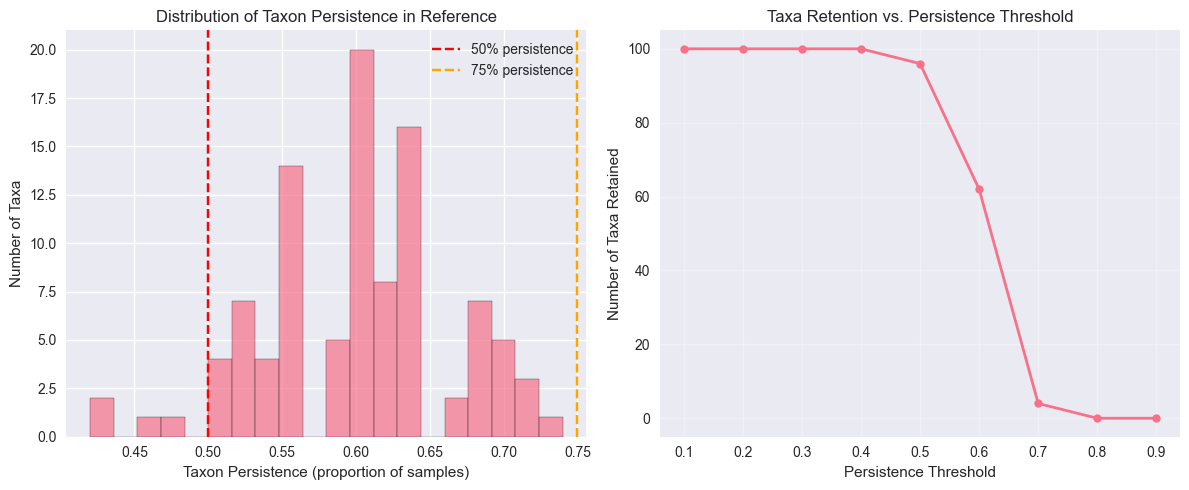

Number of taxa retained at different thresholds:
  0.10: 100 taxa
  0.20: 100 taxa
  0.30: 100 taxa
  0.40: 100 taxa
  0.50: 96 taxa
  0.60: 62 taxa
  0.70: 4 taxa
  0.80: 0 taxa
  0.90: 0 taxa


In [5]:
# Analyze persistence
pers_results = persistence_analysis(ref_data)

# Plot persistence distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Histogram of persistence values
ax1.hist(pers_results['persistence'], bins=20, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Taxon Persistence (proportion of samples)')
ax1.set_ylabel('Number of Taxa')
ax1.set_title('Distribution of Taxon Persistence in Reference')
ax1.axvline(x=0.5, color='red', linestyle='--', label='50% persistence')
ax1.axvline(x=0.75, color='orange', linestyle='--', label='75% persistence')
ax1.legend()

# Number of taxa retained at different thresholds
ax2.plot(pers_results['thresholds'], pers_results['taxa_persisted'], 'o-', linewidth=2, markersize=6)
ax2.set_xlabel('Persistence Threshold')
ax2.set_ylabel('Number of Taxa Retained')
ax2.set_title('Taxa Retention vs. Persistence Threshold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Number of taxa retained at different thresholds:")
for thresh, count in zip(pers_results['thresholds'], pers_results['taxa_persisted']):
    print(f"  {thresh:.2f}: {count} taxa")

## 4. Basic RPD Calculation

Now let's calculate RPD scores using a persistence threshold of 0.75 (taxa must be present in at least 75% of reference samples).

RPD scores shape: (20,)
RPD scores range: [0.2943, 0.3797]
Mean RPD score: 0.3284 ± 0.0225


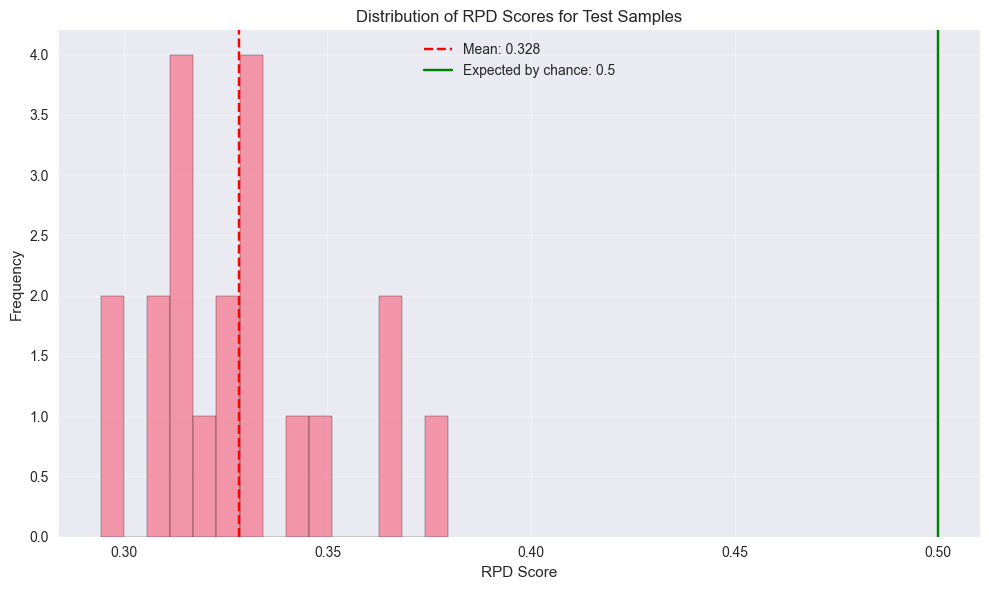

In [10]:
# Calculate RPD with persistence threshold of 0.75
rpd_scores = calc_rpd(ref_data, test_data, ref_pers=0.6)

print(f"RPD scores shape: {rpd_scores.shape}")
print(f"RPD scores range: [{rpd_scores.min():.4f}, {rpd_scores.max():.4f}]")
print(f"Mean RPD score: {np.mean(rpd_scores):.4f} ± {np.std(rpd_scores):.4f}")

# Plot distribution of RPD scores
plt.figure(figsize=(10, 6))
plt.hist(rpd_scores, bins=15, edgecolor='black', alpha=0.7)
plt.xlabel('RPD Score')
plt.ylabel('Frequency')
plt.title('Distribution of RPD Scores for Test Samples')
plt.axvline(x=np.mean(rpd_scores), color='red', linestyle='--', 
             label=f'Mean: {np.mean(rpd_scores):.3f}')
plt.axvline(x=0.5, color='green', linestyle='-', 
             label='Expected by chance: 0.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. RPD with Taxon-Level Scores

Let's also calculate taxon-level scores to see which specific taxa contribute most to the deviation.

In [7]:
# Calculate RPD with taxon-level scores
taxon_rpd, sample_rpd = calc_rpd(ref_data, test_data, ref_pers=0.75, taxon_scores=True)

print(f"Taxon-level RPD shape: {taxon_rpd.shape}")
print(f"Sample-level RPD shape: {sample_rpd.shape}")

# Verify that sample-level scores match
print(f"Sample RPD scores match: {np.allclose(sample_rpd, rpd_scores)}")

# Analyze taxon-level contributions
mean_taxon_rpd = np.nanmean(taxon_rpd, axis=0)
std_taxon_rpd = np.nanstd(taxon_rpd, axis=0)

# Find top contributing taxa (highest mean deviation)
top_taxa_idx = np.argsort(mean_taxon_rpd)[::-1][:10]

print("\nTop 10 taxa contributing to RPD deviation:")
for i, idx in enumerate(top_taxa_idx):
    print(f"  {i+1}. Taxon {idx}: {mean_taxon_rpd[idx]:.4f} ± {std_taxon_rpd[idx]:.4f}")

Taxon-level RPD shape: (20, 0)
Sample-level RPD shape: (20,)
Sample RPD scores match: True

Top 10 taxa contributing to RPD deviation:


## 6. Visualizing Taxon-Level Contributions

Let's create a heatmap to visualize how different taxa contribute to the RPD scores across samples.

In [8]:
# Create heatmap of taxon-level RPD (first 15 taxa for clarity)
n_taxa_to_show = min(15, taxon_rpd.shape[1])
taxon_subset = taxon_rpd[:, :n_taxa_to_show]

plt.figure(figsize=(12, 8))
sns.heatmap(taxon_subset.T, 
            cmap='viridis',
            cbar_kws={'label': 'Taxon-level RPD Deviation'},
            xticklabels=[f'Sample {i+1}' for i in range(taxon_subset.shape[0])],
            yticklabels=[f'Taxon {i}' for i in range(n_taxa_to_show)])
plt.title('Taxon-Level RPD Contributions (First 15 Taxa)')
plt.xlabel('Test Samples')
plt.ylabel('Taxa')
plt.tight_layout()
plt.show()

# Alternative visualization: boxplot of taxon contributions
plt.figure(figsize=(14, 6))
box_data = [taxon_rpd[:, i][~np.isnan(taxon_rpd[:, i])] for i in range(taxon_rpd.shape[1])]
valid_indices = [i for i, data in enumerate(box_data) if len(data) > 0]
box_data_valid = [box_data[i] for i in valid_indices]

if len(box_data_valid) > 0:
    plt.boxplot(box_data_valid[:20])  # Show first 20 taxa with data
    plt.xlabel('Taxon Index')
    plt.ylabel('Taxon-level RPD Deviation')
    plt.title('Distribution of Taxon-Level RPD Deviations')
    plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

ValueError: zero-size array to reduction operation fmin which has no identity

<Figure size 1200x800 with 0 Axes>

## 7. Relationship Between RPD and Community Differences

Let's demonstrate how RPD scores relate to known differences between communities by creating test datasets with varying degrees of difference from the reference.

C:\Users\matth\OneDrive\home\RPD\rpd-python\rpd\core.py:170: RuntimeWarning: Mean of empty slice
  rpd_vector = np.nanmean(ratio_diff_mat, axis=1)
C:\Users\matth\AppData\Local\Temp\ipykernel_2616\594851134.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(box_data, labels=[f'Factor {f}' for f in similarity_factors])


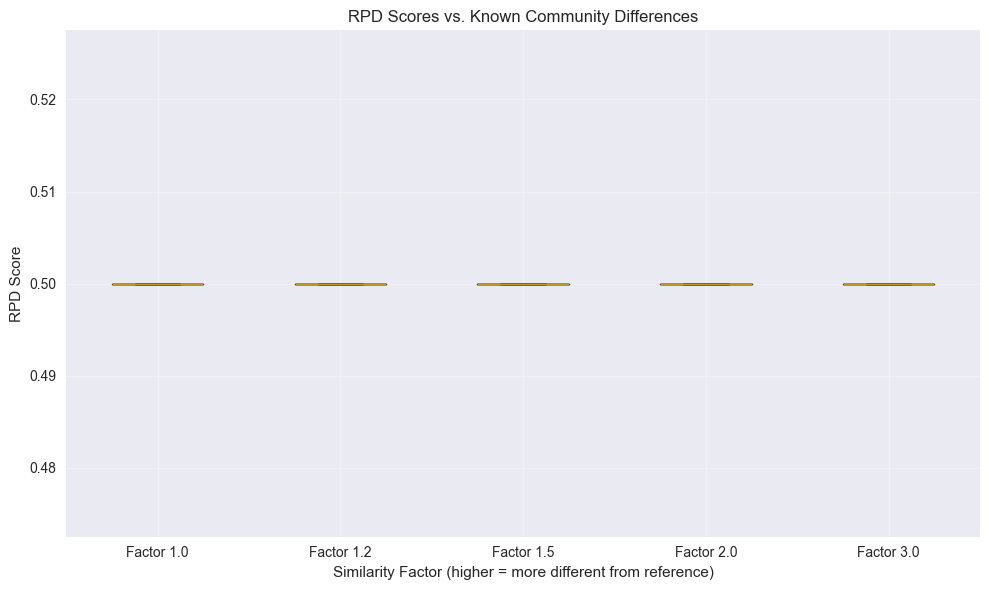

Mean RPD scores for each similarity factor:
  Factor 1.0: 0.5000
  Factor 1.2: 0.5000
  Factor 1.5: 0.5000
  Factor 2.0: 0.5000
  Factor 3.0: 0.5000


In [9]:
# Create test datasets with varying similarity to reference
np.random.seed(123)  # For reproducibility
n_simulations = 5
similarity_factors = [1.0, 1.2, 1.5, 2.0, 3.0]  # 1.0 = identical, higher = more different

all_rpd_scores = []
labels = []

for factor in similarity_factors:
    # Create test data by shifting the distribution
    if factor == 1.0:
        # Identical to reference
        test_sim = ref_data.copy()
    else:
        # Modify parameters to create increasingly different communities
        shape_shift = 2.0 * factor
        scale_shift = 2.0 / factor
        test_sim = np.random.gamma(shape=shape_shift, scale=scale_shift, size=ref_data.shape)
        test_sim[test_sim < np.percentile(test_sim, 40)] = 0
    
    # Calculate RPD
    rpd_sim = calc_rpd(ref_data, test_sim, ref_pers=0.75)
    all_rpd_scores.append(rpd_sim)
    labels.extend([f'Factor {factor}'] * len(rpd_sim))

# Plot results
plt.figure(figsize=(10, 6))
box_data = [all_rpd_scores[i] for i in range(len(all_rpd_scores))]
plt.boxplot(box_data, labels=[f'Factor {f}' for f in similarity_factors])
plt.ylabel('RPD Score')
plt.xlabel('Similarity Factor (higher = more different from reference)')
plt.title('RPD Scores vs. Known Community Differences')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("Mean RPD scores for each similarity factor:")
for i, factor in enumerate(similarity_factors):
    mean_rpd = np.mean(all_rpd_scores[i])
    print(f"  Factor {factor}: {mean_rpd:.4f}")

## 8. Saving and Loading Results

Finally, let's show how to save RPD results for later use.

In [ ]:
# Save RPD scores to CSV
import pandas as pd

results_df = pd.DataFrame({
    'sample_id': [f'test_sample_{i+1}' for i in range(len(rpd_scores))],
    'rpd_score': rpd_scores
})

results_df.to_csv('rpd_results.csv', index=False)
print("RPD scores saved to 'rpd_results.csv'")
print(results_df.head())

# Save taxon-level results if calculated
if 'taxon_rpd' in locals():
    taxon_df = pd.DataFrame(taxon_rpd, 
                          index=[f'test_sample_{i+1}' for i in range(taxon_rpd.shape[0])],
                          columns=[f'taxon_{i}' for i in range(taxon_rpd.shape[1])])
    taxon_df.to_csv('taxon_rpd_results.csv')
    print("\nTaxon-level RPD saved to 'taxon_rpd_results.csv'")
    print(taxon_df.iloc[:3, :5])  # Show first 3 samples, first 5 taxa

## 9. Summary

In this demo, we've shown how to:
1. Install and import the RPD Python package
2. Load or generate example microbial community data
3. Analyze taxon persistence to choose appropriate thresholds
4. Calculate sample-level RPD scores
5. Calculate taxon-level RPD scores for detailed analysis
6. Visualize RPD distributions and taxon contributions
7. Demonstrate that RPD scores increase with known community differences
8. Save results for downstream analysis

The RPD method provides a robust way to quantify community dissimilarity that is less sensitive to sequencing depth and total community size than traditional distance metrics.